iteration 0 loss func 8.043086224910702 learning rate 0.5
iteration 100 loss func 1.7666695102903796 learning rate 0.255
iteration 200 loss func 0.3807361400407594 learning rate 0.5
iteration 300 loss func 0.4891887869926805 learning rate 0.255
iteration 400 loss func 0.24338213791075627 learning rate 0.5
iteration 500 loss func 0.18504601477091245 learning rate 0.255
iteration 600 loss func 0.15722489019161412 learning rate 0.5
iteration 700 loss func 0.19673121040342523 learning rate 0.255
iteration 800 loss func 0.14921336371339083 learning rate 0.5
iteration 900 loss func 0.1435505660726732 learning rate 0.255
iteration 1000 loss func 0.15207725923969498 learning rate 0.5
iteration 1100 loss func 0.11159744491584687 learning rate 0.255
iteration 1200 loss func 0.11431388836690129 learning rate 0.5
iteration 1300 loss func 0.1822127968553869 learning rate 0.255
iteration 1400 loss func 0.10502679852568592 learning rate 0.5
iteration 1500 loss func 0.17915498787744535 learning rate 0

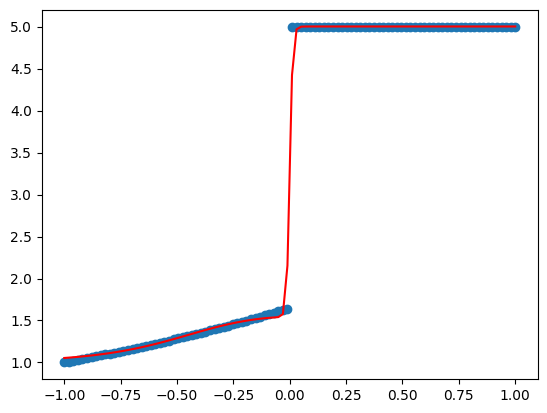

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jul  1 11:05:29 2023

@author: whadyimac
https://www.analyticsvidhya.com/blog/2023/01/gradient-descent-vs-backpropagation-whats-the-difference/#
http://cs231n.stanford.edu/slides/2018/cs231n_2018_ds02.pdf
https://cklixx.people.wm.edu/teaching/math400/Annette-paper.pdf
https://machinelearningmastery.com/weight-initialization-for-deep-learning-neural-networks/
https://kevintham.github.io/dsblog/2018/02/26/the-backpropagation-algorithm.html
https://www.cs.toronto.edu/~rgrosse/courses/csc2541_2022/tutorials/tut01.pdf
https://www.v7labs.com/blog/neural-networks-activation-functions
"""
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def f(x):
    if x<=0.5:
      y=np.exp(x)
    else:
      y=5
    return y

def sig(x):
    y=1.0/(1.0+np.exp(-x))
    return y

nn=3
def m(x,*params):
#w=[w000,w001,w002,w100,w101,w102,w110,w111,w112,w120,w121,w122,w200,w210,w220,b20,b21,b22,b30]
#    0    1    2    3    4    5    6   7     8    9   10   11   12    13   14  15  16  17  18
#    w=np.zeros((3,3,3))
#    b=np.zeros((4,3))
#    w[0,0,0]=params[0][0]
#    w[0,0,1]=params[0][1]
#    w[0,0,2]=params[0][2]
#    w[1,0,0]=params[0][3]
#    w[1,0,1]=params[0][4]
#    w[1,0,2]=params[0][5]
#    w[1,1,0]=params[0][6]
#    w[1,1,1]=params[0][7]
#    w[1,1,2]=params[0][8]
#    w[1,2,0]=params[0][9]
#    w[1,2,1]=params[0][10]
#    w[1,2,2]=params[0][11]
#    w[2,0,0]=params[0][12]
#    w[2,1,0]=params[0][13]
#    w[2,2,0]=params[0][14]
#    b[2,0]=params[0][15]
#    b[2,1]=params[0][16]
#    b[2,2]=params[0][17]
#    b[3,0]=params[0][18]

#    r0=w[0,0,0]*x
#    r1=w[0,0,1]*x
#    r2=w[0,0,2]*x
#    r3=w[1,0,0]*sig(r0)
#    r4=w[1,0,1]*sig(r0)
#    r5=w[1,0,2]*sig(r0)
#    r6=w[1,1,0]*sig(r1)
#    r7=w[1,1,1]*sig(r1)
#    r8=w[1,1,2]*sig(r1)
#    r9=w[1,2,0]*sig(r2)
#    r10=w[1,2,1]*sig(r2)
#    r11=w[1,2,2]*sig(r2)
#    r12=sig(r3+r6+r9+b[2,0])
#    r13=sig(r4+r7+r10+b[2,1])
#    r14=sig(r5+r8+r11+b[2,2])
#    r15=w[2,0,0]*r12+w[2,1,0]*r13+w[2,2,0]*r14+b[3,0]
#    y=r15

    w=np.zeros((3,nn,nn))
    b=np.zeros((4,nn))

    icount=0
    for i in range(nn):
      w[0,0,i]=params[0][icount]
      icount+=1
    for i in range(nn):
      for j in range(nn):
        w[1,i,j]=params[0][icount]
        icount+=1
    for i in range(nn):
      w[2,i,0]=params[0][icount]
      icount+=1
    for i in range(nn):
      b[2,i]=params[0][icount]
      icount+=1
    b[3,0]=params[0][icount]

    r0=np.zeros(nn)
    rij=np.zeros((nn,nn))
    r1=np.zeros(nn)

    for i in range(nn):
      r0[i]=w[0,0,i]*x

    for i in range(nn):
      for j in range(nn):
        rij[i,j]=w[1,i,j]*sig(r0[i])

    for i in range(nn):
      for j in range(nn):
        r1[i]+=rij[j,i]
      r1[i]=sig(r1[i]+b[2,i])

    NN=0.0
    for i in range(nn):
      NN+=w[2,i,0]*r1[i]
    NN+=b[3,0]

    y=NN
    return y

def E(p,ndata,nrandom,iflag):
    #iflag=0 si no se calcula E2 y 1 si se calcula E2
    ep=np.zeros(ndata)
    E2=0
    E2random=0
    if iflag==1:
        for i in range(ndata):
            ep[i]=(y[i]-m(x[i],p))**2
            E2+=ep[i]
        E2=E2/ndata
    if iflag==0:
        ep[nrandom]=(y[nrandom]-m(x[nrandom],p))**2
        E2random=ep[nrandom]
    return E2,E2random,ep

def grad(p,ndata,nrandom):
    n=len(p)
    y=np.zeros(n)
    dp=np.zeros(n)
    eps=1.0e-6
    for i in range(n):
        dp[i]=eps
#        y[i]=(E(p+dp,ndata,nrandom,1)[0]-E(p,ndata,nrandom,1)[0])/eps #whole gradient
        y[i]=(E(p+dp,ndata,nrandom,0)[1]-E(p,ndata,nrandom,0)[1])/eps #stochastic subgradient
        dp[i]=0.0
    return y


n=100
x=np.linspace(0,1,n)
y=np.zeros(n)
for i in range(n):
    y[i]=f(x[i])
x=np.linspace(-1,1,n)  #trying to normalaze data althoug not always necessary

nparams=nn+nn*nn+2*nn+1
np.random.seed(177)
#x0=np.random.rand(nparams)
#x0=np.ones(nparams)+(np.random.rand(nparams)-0.5)*0.001

#options={'disp':True}

#lstage=1
#def callback(xk):
#  global lstage
#  print('Learning stage',lstage,'fun',E(xk,n))
#  lstage+=1

#parameters=minimize(E,x0,args=(n),method='Powell',callback=callback,options=options)
#p=parameters.x

lr=0.1
lrmax=0.5
lrmin=0.01
Tmax=200
itermax=100000

a=-0.5
b=0.5
p0=a+(b-a)*np.random.rand(nparams)
c=np.ones(nparams) #scale factors
c=np.abs(p0)+1
np.where(c>1,c,1.0)

for i in range(itermax):
    nrand=np.random.randint(n)
    S=grad(np.multiply(c,p0),n,nrand)
    p=p0-lr*np.divide(S,c**2)
    p0[:]=p
    lr=lrmin+0.5*(lrmax-lrmin)*(1.0+np.cos(np.mod(i,Tmax)/Tmax*np.pi))
    if np.mod(i,100)==0: print('iteration',i,'loss func',E(np.multiply(c,p),n,nrand,1)[0],'learning rate',lr)
    c=np.abs(p0)+1 #rescale at each iteration
    np.where(c>1,c,1.0)
p=np.multiply(c,p) #remove scale

nm=100
xm=np.linspace(x[0],x[-1],nm)
ym=np.zeros(nm)
for i in range(nm):
    ym[i]=m(xm[i],p)


plt.figure()
plt.plot(x,y,'o')
plt.plot(xm,ym,'r-')


#derivative calculation
#x=1.5
#dx=1.0e-6
#dmdx=(m(x+dx,parameters.x)-m(x,parameters.x))/dx
#fd=(f(x+dx)-f(x))/dx
#print('exact derivative',np.exp(x))
#print('model derivative',dmdx)
#print('finite differences',fd)


















In [ ]:
p

array([  13.129979  ,    4.17587467,    5.84604624,  -12.99089444,
         -3.91256175,  -58.87247956,   -5.04745052,   -4.9918208 ,
        -47.88792782,   -5.82133324,   -0.59261493,  -67.68675152,
         -3.51271126,   -1.99331535,    2.26133168,   10.80393326,
         -1.31891296, -236.53109388,    5.00890547])